# 2.2 多値変数 (Multinomial Variables)
本ノートブックでは、$K > 2$ 個の離散状態を取りうる変数のモデル化である**カテゴリカル分布**、**多項分布 (Multinomial distribution)**、そしてその共役事前分布である**ディリクレ分布 (Dirichlet distribution)** について詳しく学びます。

## 2.2.1 1-of-K 表現と多項分布

$K$ 個の相互排他的な状態を取りうる確率変数を表すために、**1-of-$K$ 表現**（ワンホットベクトル）を用います。
$K=6$ のサイコロの目が 3 であった場合、
$$ \mathbf{x} = (0, 0, 1, 0, 0, 0)^T $$
のように表します。要素は $x_k \in \{0, 1\}$ であり、常に $\sum_{k=1}^K x_k = 1$ を満たします。

### カテゴリカル分布
各状態 $k$ が生起する確率を $\mu_k = p(x_k = 1)$ と置くと（$\mu_k \ge 0, \sum_{k=1}^K \mu_k = 1$）、単一の観測 $\mathbf{x}$ の確率は以下のように表せます。

$$ p(\mathbf{x} | \boldsymbol{\mu}) = \prod_{k=1}^K \mu_k^{x_k} $$

### 多項分布 (Multinomial Distribution)
サイズ $N$ の独立な観測データセット $\mathcal{D} = \{\mathbf{x}_1, \dots, \mathbf{x}_N\}$ において、状態 $k$ が観測された回数を $m_k = \sum_{n=1}^N x_{nk}$ と置きます。
回数ベクトル $\mathbf{m} = (m_1, \dots, m_K)^T$ （ただし $\sum_{k=1}^K m_k = N$）の同時分布は**多項分布**で与えられます。

$$ \mathrm{Mult}(m_1, \dots, m_K | \boldsymbol{\mu}, N) = \binom{N}{m_1 m_2 \dots m_K} \prod_{k=1}^K \mu_k^{m_k} $$

ここで多項係数は $\binom{N}{m_1 \dots m_K} = \frac{N!}{m_1! m_2! \dots m_K!}$ です。

### ラグランジュ未定乗数法による最尤推定
対数尤度関数は以下の通りです。
$$ \ln p(\mathcal{D} | \boldsymbol{\mu}) = \sum_{k=1}^K m_k \ln \mu_k $$

制約条件 $\sum_{k=1}^K \mu_k = 1$ を満たすために、ラグランジュ乗数 $\lambda$ を導入したラグランジュ関数を最大化します。
$$ L(\boldsymbol{\mu}, \lambda) = \sum_{k=1}^K m_k \ln \mu_k + \lambda \left( \sum_{k=1}^K \mu_k - 1 \right) $$

$\mu_k$ について微分して 0 と置きます。
$$ \frac{\partial L}{\partial \mu_k} = \frac{m_k}{\mu_k} + \lambda = 0 \implies \mu_k = -\frac{m_k}{\lambda} $$

両辺をすべての $k$ について足し合わせると、$\sum_{k=1}^K \mu_k = 1$ かつ $\sum_{k=1}^K m_k = N$ より、
$$ 1 = -\frac{N}{\lambda} \implies \lambda = -N $$

したがって、最尤推定量は直感通り各状態の標本比率となります。
$$ \mu_k^{\mathrm{ML}} = \frac{m_k}{N} $$

## 2.2.2 ディリクレ分布 (The Dirichlet Distribution)

多項分布のパラメータ $\boldsymbol{\mu}$ に対する共役事前分布を考えます。
多項尤度の関数形 $\prod_{k=1}^K \mu_k^{m_k}$ から、共役事前分布は $\prod_{k=1}^K \mu_k^{\alpha_k - 1}$ に比例する形である必要があります。
これが**ディリクレ分布**です。

$$ \mathrm{Dir}(\boldsymbol{\mu} | \boldsymbol{\alpha}) = \frac{\Gamma(\alpha_0)}{\Gamma(\alpha_1) \dots \Gamma(\alpha_K)} \prod_{k=1}^K \mu_k^{\alpha_k - 1} $$

ここで $\alpha_0 = \sum_{k=1}^K \alpha_k$ であり、パラメータは $\mu_k \ge 0$ かつ $\sum_{k=1}^K \mu_k = 1$ を満たす $K-1$ 次元の**単体 (Simplex)** 上に制限されます。

### モーメント（期待値・分散・共分散）
- 期待値: $\mathbb{E}[\mu_k] = \frac{\alpha_k}{\alpha_0}$
- 分散: $\mathrm{var}[\mu_k] = \frac{\alpha_k (\alpha_0 - \alpha_k)}{\alpha_0^2 (\alpha_0 + 1)}$
- 共分散 ($j \ne k$): $\mathrm{cov}[\mu_j, \mu_k] = -\frac{\alpha_j \alpha_k}{\alpha_0^2 (\alpha_0 + 1)}$

### 事後分布の導出
観測カウント $\mathbf{m} = (m_1, \dots, m_K)^T$ が得られたとき、事後分布は以下のように更新されます。

$$ p(\boldsymbol{\mu} | \mathcal{D}, \boldsymbol{\alpha}) \propto p(\mathcal{D} | \boldsymbol{\mu}) p(\boldsymbol{\mu} | \boldsymbol{\alpha}) \propto \prod_{k=1}^K \mu_k^{\alpha_k + m_k - 1} $$

規格化定数を合わせると、
$$ p(\boldsymbol{\mu} | \mathcal{D}, \boldsymbol{\alpha}) = \mathrm{Dir}(\boldsymbol{\mu} | \boldsymbol{\alpha} + \mathbf{m}) $$

ベータ分布の場合と同様に、事前ハイパーパラメータ $\alpha_k$ はカテゴリ $k$ の事前の仮想的な観測回数（有効観測数）として直感的に理解できます。

## 2.2.3 単体上のディリクレ分布の可視化 (PRML Figure 2.4 / 2.5 の再現)

$K=3$ の場合、確率ベクトル $(\mu_1, \mu_2, \mu_3)$ は2次元平面上の正三角形（2-単体）を形成します。
様々なパラメータ $\boldsymbol{\alpha} = (\alpha_1, \alpha_2, \alpha_3)$ におけるディリクレ密度の形状を等高線で可視化します。

Plot saved to: result/fig2_4_dirichlet_distributions.png


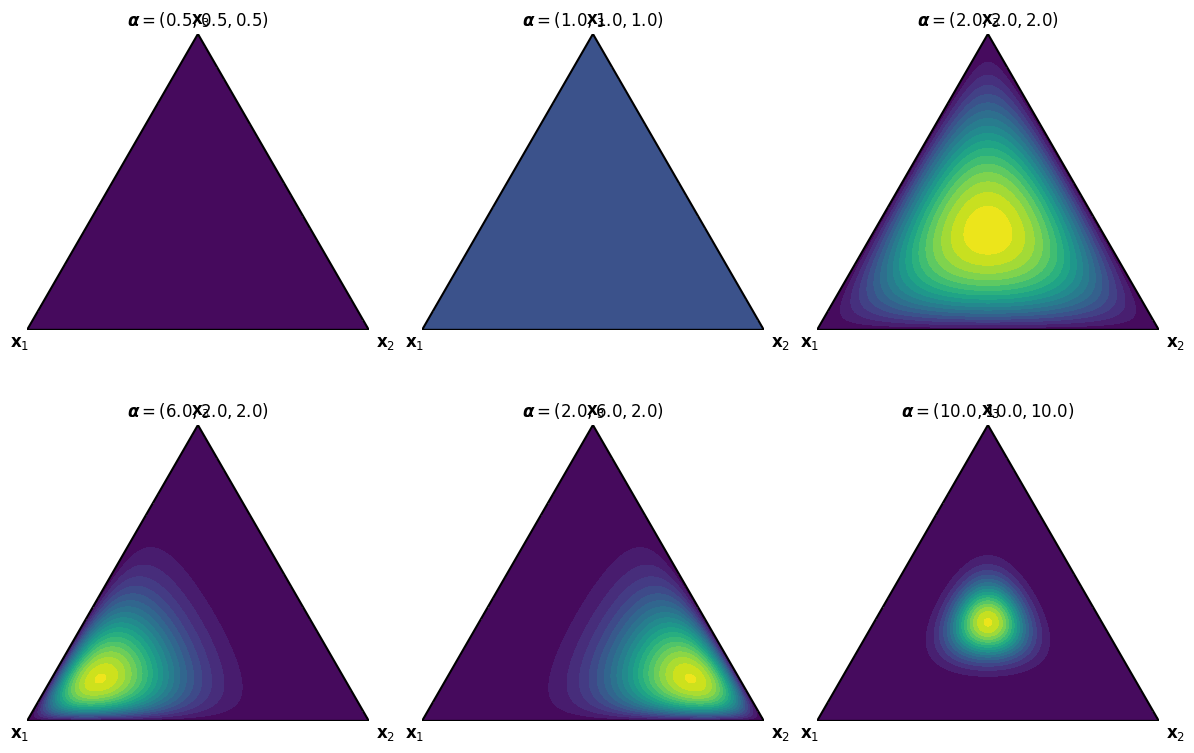

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.distribution_utils import plot_dirichlet_contour
setup_style()

alphas = [
    np.array([0.5, 0.5, 0.5]),
    np.array([1.0, 1.0, 1.0]),
    np.array([2.0, 2.0, 2.0]),
    np.array([6.0, 2.0, 2.0]),
    np.array([2.0, 6.0, 2.0]),
    np.array([10.0, 10.0, 10.0])
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, alpha in zip(axes.flat, alphas):
    plot_dirichlet_contour(alpha, n_grid=200, ax=ax, cmap='viridis')
    ax.set_title(r'$\boldsymbol{\alpha} = (' + f'{alpha[0]}, {alpha[1]}, {alpha[2]}' + r')$', fontsize=12)

plt.tight_layout()
save_plot(fig, 'result', 'fig2_4_dirichlet_distributions.png')
plt.show()

## 2.2.4 ディリクレ事後分布のベイズ更新シミュレーション

事前分布 $\boldsymbol{\alpha} = (1, 1, 1)$（平坦な一様分布）から出発し、
3値カテゴリカルデータが順次観測されたときの事後分布の変化を可視化します。

Plot saved to: result/fig2_dirichlet_posterior_update.png


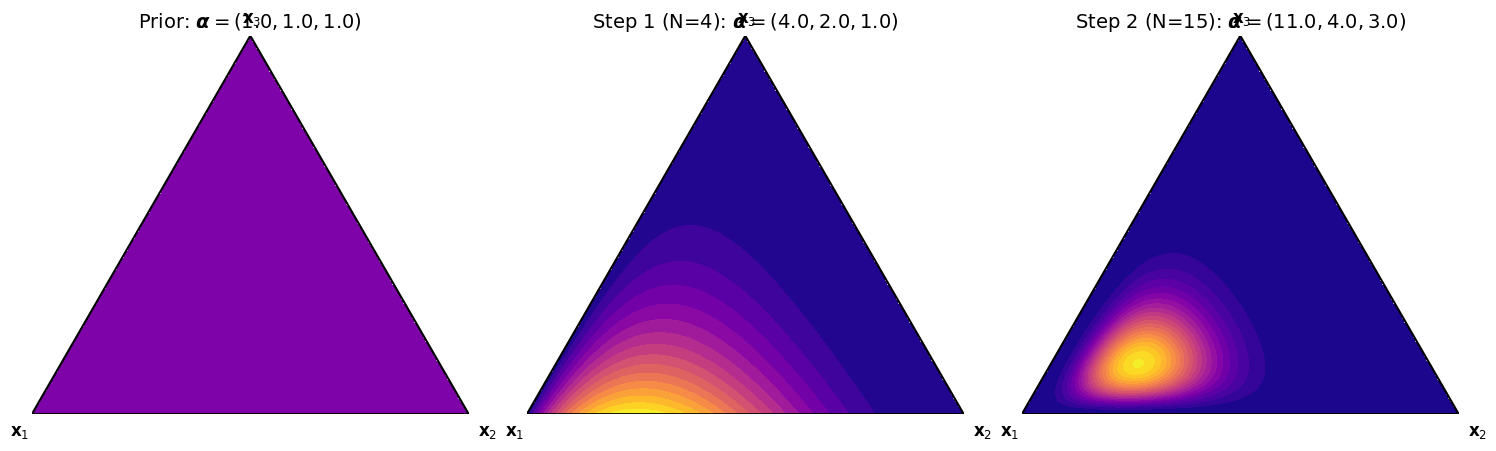

In [2]:
# 観測カウントのシミュレーション
# 例えば、カテゴリ1が10回、カテゴリ2が3回、カテゴリ3が2回観測された場合
prior_alpha = np.array([1.0, 1.0, 1.0])
counts_step1 = np.array([3, 1, 0])
counts_step2 = np.array([10, 3, 2])

alpha_step1 = prior_alpha + counts_step1
alpha_step2 = prior_alpha + counts_step2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_dirichlet_contour(prior_alpha, ax=axes[0], cmap='plasma')
axes[0].set_title(r'Prior: $\boldsymbol{\alpha} = (' + f'{prior_alpha[0]}, {prior_alpha[1]}, {prior_alpha[2]}' + r')$')

plot_dirichlet_contour(alpha_step1, ax=axes[1], cmap='plasma')
axes[1].set_title(r'Step 1 (N=4): $\boldsymbol{\alpha} = (' + f'{alpha_step1[0]}, {alpha_step1[1]}, {alpha_step1[2]}' + r')$')

plot_dirichlet_contour(alpha_step2, ax=axes[2], cmap='plasma')
axes[2].set_title(r'Step 2 (N=15): $\boldsymbol{\alpha} = (' + f'{alpha_step2[0]}, {alpha_step2[1]}, {alpha_step2[2]}' + r')$')

plt.tight_layout()
save_plot(fig, 'result', 'fig2_dirichlet_posterior_update.png')
plt.show()